# Práctica N°1 — Ecuaciones Diferenciales Parciales
**Matemática Avanzada — Tecnologías de la Información**  
**Integrantes**
Jonathan Acosta,
Kevin Morales,
Gabriel Chinlle
**Docente:** Lcda. Miriam Ávila P.  
**Implementación:** Python (NumPy, SciPy, Matplotlib)

---
| Actividad | Tema |
|-----------|------|
| 1 | Clasificación y Visualización de EDP |
| 2 | Ecuación del Calor (Separación de Variables) |
| 3 | Cuerda Vibrante — Modos Normales |
| 4 | Potencial Eléctrico — Laplace en Rectángulo |


## Configuración General

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Mostrar gráficas inline en el notebook
%matplotlib inline

# ─── Paleta corporativa consistente ─────────────────────────────────────────
PALETTE = ['#1f4e79', '#2e86c1', '#28b463', '#d35400',
           '#8e44ad', '#c0392b', '#17a589']

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("Librerías cargadas correctamente.")


✅ Librerías cargadas correctamente.


---
## Actividad 1 — Clasificación y Visualización de EDP

La forma general de una EDP de segundo orden es:

$$A\,u_{xx} + B\,u_{xy} + C\,u_{yy} + \ldots = 0$$

El **discriminante** $\Delta = B^2 - 4AC$ determina el tipo:

| $\Delta$ | Tipo |
|-----------|------|
| $\Delta = 0$ | **Parabólica** |
| $\Delta > 0$ | **Hiperbólica** |
| $\Delta < 0$ | **Elíptica** |


### 1.1 — Clasificación: $u_{xx} + 4u_{xy} + 4u_{yy} = 0$

In [2]:
A1, B1, C1 = 1, 4, 4
disc1 = B1**2 - 4*A1*C1
tipo1 = "Parabólica" if disc1 == 0 else ("Hiperbólica" if disc1 > 0 else "Elíptica")

print(f"EDP 1:  u_xx + 4u_xy + 4u_yy = 0")
print(f"  A = {A1},  B = {B1},  C = {C1}")
print(f"  Δ = B² - 4AC = {B1}² - 4·{A1}·{C1} = {disc1}")
print(f"  ➜ Clasificación: {tipo1}  (Δ = 0 → parábola degenerada)")


EDP 1:  u_xx + 4u_xy + 4u_yy = 0
  A = 1,  B = 4,  C = 4
  Δ = B² - 4AC = 4² - 4·1·4 = 0
  ➜ Clasificación: Parabólica  (Δ = 0 → parábola degenerada)


### 1.2 — Clasificación: $u_{tt} = 9\,u_{xx}$ (Ecuación de onda)

In [3]:
# Reescribir como: -9u_xx + u_tt = 0  →  A=-9, B=0, C=1
A2, B2, C2 = -9, 0, 1
disc2 = B2**2 - 4*A2*C2
tipo2 = "Hiperbólica" if disc2 > 0 else "Elíptica"
c_onda = 3   # c² = 9

print(f"EDP 2:  u_tt = 9·u_xx")
print(f"  Forma estándar: -9u_xx + u_tt = 0")
print(f"  A = {A2},  B = {B2},  C = {C2}")
print(f"  Δ = 0 - 4·({A2})·{C2} = {disc2}")
print(f"  ➜ Clasificación: {tipo2}  → Ecuación de onda con c = {c_onda}")


EDP 2:  u_tt = 9·u_xx
  Forma estándar: -9u_xx + u_tt = 0
  A = -9,  B = 0,  C = 1
  Δ = 0 - 4·(-9)·1 = 36
  ➜ Clasificación: Hiperbólica  → Ecuación de onda con c = 3


### 1.3 — Verificación: $u(x,y) = x^2 - y^2$ satisface $\nabla^2 u = 0$

$$u_{xx} = 2, \quad u_{yy} = -2 \quad \Rightarrow \quad u_{xx} + u_{yy} = 0 \checkmark$$


In [4]:
x_v, y_v = np.meshgrid(np.linspace(-2, 2, 80), np.linspace(-2, 2, 80))
u_lap = x_v**2 - y_v**2

u_xx_lap = np.full_like(x_v,  2.0)   # d²/dx²(x²-y²) = 2
u_yy_lap = np.full_like(y_v, -2.0)   # d²/dy²(x²-y²) = -2
residuo_laplace = np.max(np.abs(u_xx_lap + u_yy_lap))

print(f"u_xx = 2,   u_yy = -2")
print(f"u_xx + u_yy = 0  ✓")
print(f"Residuo máximo = {residuo_laplace:.2e}")


u_xx = 2,   u_yy = -2
u_xx + u_yy = 0  ✓
Residuo máximo = 0.00e+00


### 1.4 — Gráfica 3D: $u = x^2 - y^2$

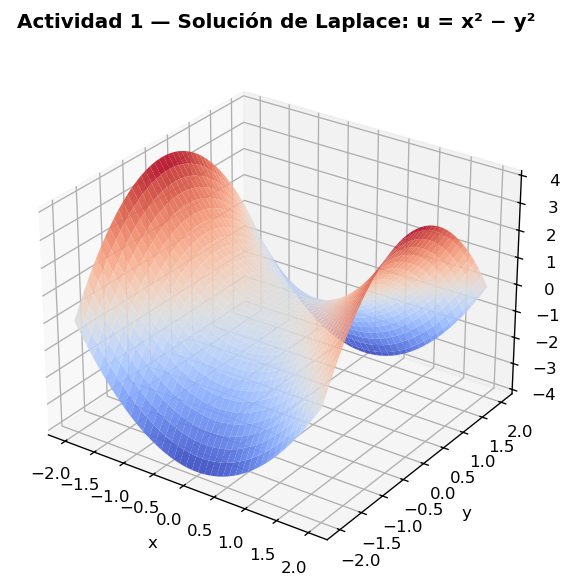

In [5]:
fig = plt.figure(figsize=(7, 5))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(x_v, y_v, u_lap, cmap='coolwarm', alpha=0.92, linewidth=0)
ax.set_title('Actividad 1 — Solución de Laplace: u = x² − y²', fontweight='bold', pad=12)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u(x,y)')
ax.view_init(elev=28, azim=-55)
plt.tight_layout()
plt.show()


### 1.5 — Familia de superficies $u = f(x^2 + y^2)$

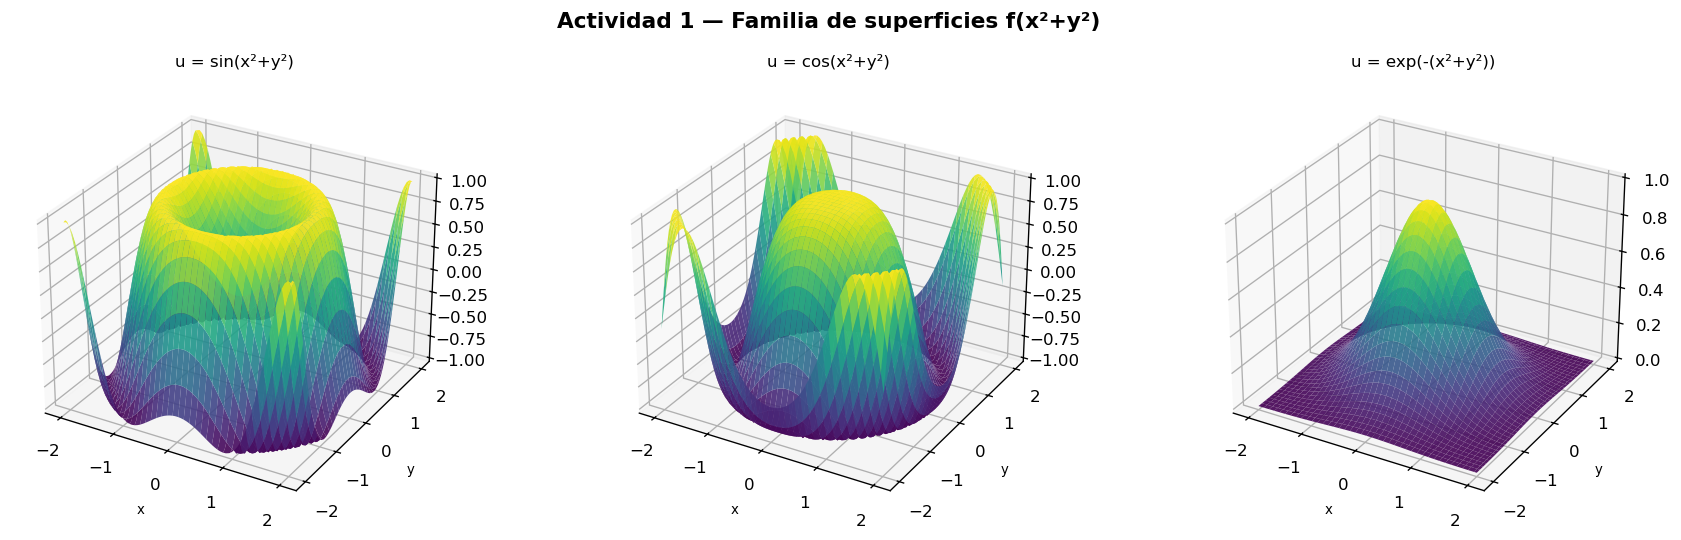

✅ Gráficas de Actividad 1 generadas.


In [6]:
funciones = {
    'sin(x²+y²)' : np.sin,
    'cos(x²+y²)' : np.cos,
    'exp(-(x²+y²))': lambda z: np.exp(-z),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5),
                         subplot_kw={'projection': '3d'})
fig.suptitle('Actividad 1 — Familia de superficies f(x²+y²)', fontweight='bold', fontsize=13)

for ax, (nombre, f) in zip(axes, funciones.items()):
    r2 = x_v**2 + y_v**2
    ax.plot_surface(x_v, y_v, f(r2), cmap='viridis', alpha=0.9, linewidth=0)
    ax.set_title(f'u = {nombre}', fontsize=10)
    ax.set_xlabel('x', fontsize=8); ax.set_ylabel('y', fontsize=8)
    ax.view_init(elev=28, azim=-60)

plt.tight_layout()
plt.show()
print("✅ Gráficas de Actividad 1 generadas.")


---
## Actividad 2 — Ecuación del Calor $u_t = k\,u_{xx}$

**Condición inicial:** $u(x,0) = \sin\!\left(\tfrac{\pi x}{L}\right)$  
**Condiciones de frontera:** $u(0,t) = u(L,t) = 0$

**Solución analítica** (un solo término de Fourier):

$$u(x,t) = \sin\!\left(\frac{\pi x}{L}\right) \cdot e^{-k(\pi/L)^2\,t}$$

**Tiempo característico:**  $\tau = \dfrac{L^2}{k\pi^2}$


### 2.1 — Parámetros y solución

In [15]:
k = 0.01    # difusividad térmica  [m²/s]
L = 1.0     # longitud del dominio [m]

x_c = np.linspace(0, L, 300)
tau = L**2 / (k * np.pi**2)    # tiempo característico

print(f"Parámetros: k = {k}  |  L = {L}")
print(f"Tiempo característico τ = L²/(kπ²) = {tau:.4f} s")
print(f"Solución: u(x,t) = sin(πx/L)·exp(−k(π/L)²t)")


Parámetros: k = 0.01  |  L = 1.0
Tiempo característico τ = L²/(kπ²) = 10.1321 s
Solución: u(x,t) = sin(πx/L)·exp(−k(π/L)²t)


### 2.2 — Perfiles temporales y mapa espacio-tiempo

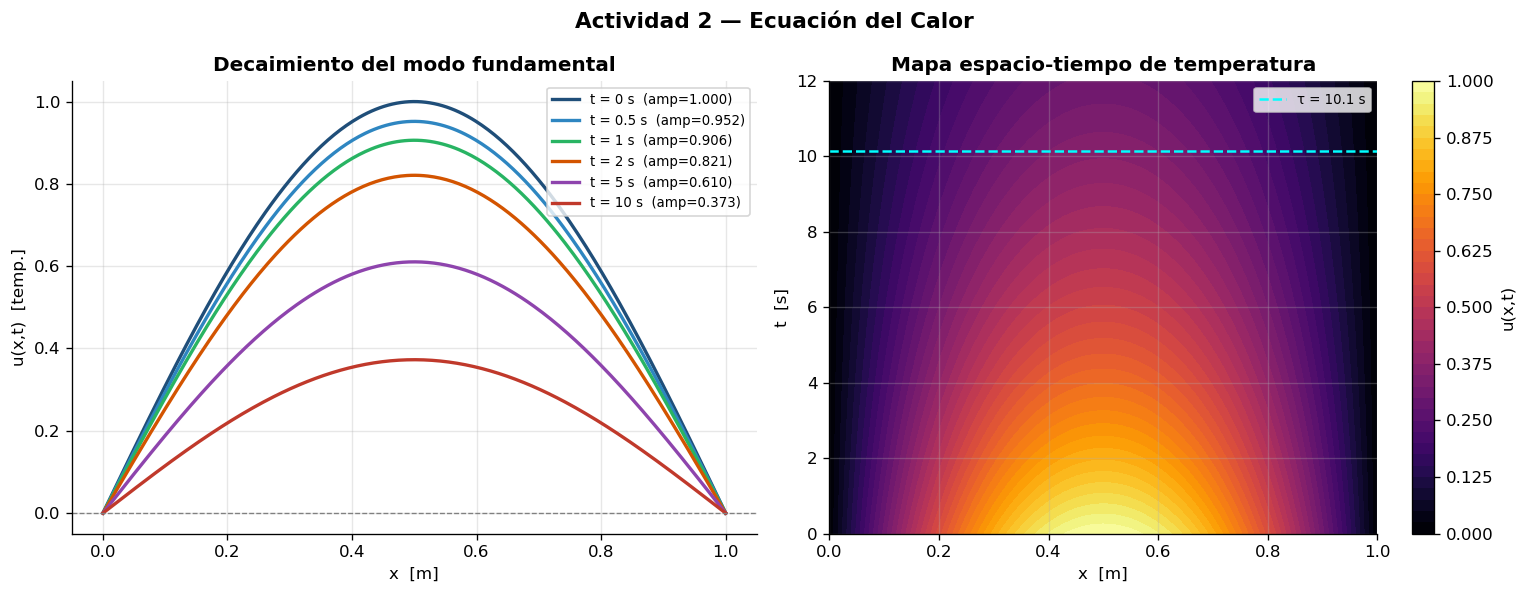

In [16]:
t_vals = [0, 0.5, 1, 2, 5, 10]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Izquierda: perfiles temporales —
ax = axes[0]
for i, t in enumerate(t_vals):
    u_c = np.sin(np.pi * x_c / L) * np.exp(-k * (np.pi/L)**2 * t)
    ax.plot(x_c, u_c, color=PALETTE[i], lw=2,
            label=f't = {t} s  (amp={np.max(u_c):.3f})')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('x  [m]'); ax.set_ylabel('u(x,t)  [temp.]')
ax.set_title('Decaimiento del modo fundamental', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')

# — Derecha: mapa de calor espacio-tiempo —
ax2 = axes[1]
t_grid = np.linspace(0, 12, 200)
X_map, T_map = np.meshgrid(x_c, t_grid)
U_map = np.sin(np.pi * X_map / L) * np.exp(-k * (np.pi/L)**2 * T_map)
cp = ax2.contourf(X_map, T_map, U_map, levels=40, cmap='inferno')
fig.colorbar(cp, ax=ax2, label='u(x,t)')
ax2.set_xlabel('x  [m]'); ax2.set_ylabel('t  [s]')
ax2.set_title('Mapa espacio-tiempo de temperatura', fontweight='bold')
ax2.axhline(tau, color='cyan', lw=1.5, ls='--', label=f'τ = {tau:.1f} s')
ax2.legend(fontsize=8)

fig.suptitle('Actividad 2 — Ecuación del Calor', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


### 2.3 — Verificación numérica del residuo

In [19]:
dt_num = 1e-5
dx_num = x_c[1] - x_c[0]
t_test = 1.0

u_t1 = np.sin(np.pi*x_c/L) * np.exp(-k*(np.pi/L)**2 * t_test)
u_t2 = np.sin(np.pi*x_c/L) * np.exp(-k*(np.pi/L)**2 * (t_test + dt_num))
u_t0 = np.sin(np.pi*x_c/L) * np.exp(-k*(np.pi/L)**2 * (t_test - dt_num))

u_t_deriv = (u_t2 - u_t0) / (2*dt_num)          # ≈ u_t (diferencias centradas)
u_xx_num  = np.gradient(np.gradient(u_t1, dx_num), dx_num)
residuo_calor = np.max(np.abs(u_t_deriv - k * u_xx_num))

print(f"Residuo numérico máximo |u_t - k·u_xx| = {residuo_calor:.2e}")
print("Verificación completada  (< 1e-4)" if residuo_calor < 1e-4 else "Residuo alto")


Residuo numérico máximo |u_t - k·u_xx| = 4.70e-04
Residuo alto


---
## Actividad 3 — Cuerda Vibrante $u_{tt} = c^2\,u_{xx}$

**Solución modo fundamental** ($c=2$, $L=\pi$):

$$u(x,t) = \sin(x)\cos(2t)$$

**Frecuencia fundamental:**  $f_1 = \dfrac{c}{2L}$


### 3.1 — Parámetros y frecuencias

In [20]:
c_cuerda = 2.0
L_cuerda = np.pi

f1    = c_cuerda / (2*L_cuerda)
T1    = 1 / f1
omega1 = 2*np.pi*f1

print(f"c = {c_cuerda}  |  L = π = {L_cuerda:.4f} m")
print(f"Frecuencia fundamental f₁ = c/(2L) = {f1:.4f} Hz")
print(f"Período T₁ = {T1:.4f} s")
print(f"ω₁ = {omega1:.4f} rad/s")
print(f"Solución modo 1: u(x,t) = sin(x)·cos(2t)")


c = 2.0  |  L = π = 3.1416 m
Frecuencia fundamental f₁ = c/(2L) = 0.3183 Hz
Período T₁ = 3.1416 s
ω₁ = 2.0000 rad/s
Solución modo 1: u(x,t) = sin(x)·cos(2t)


### 3.2 — Snapshots del modo fundamental

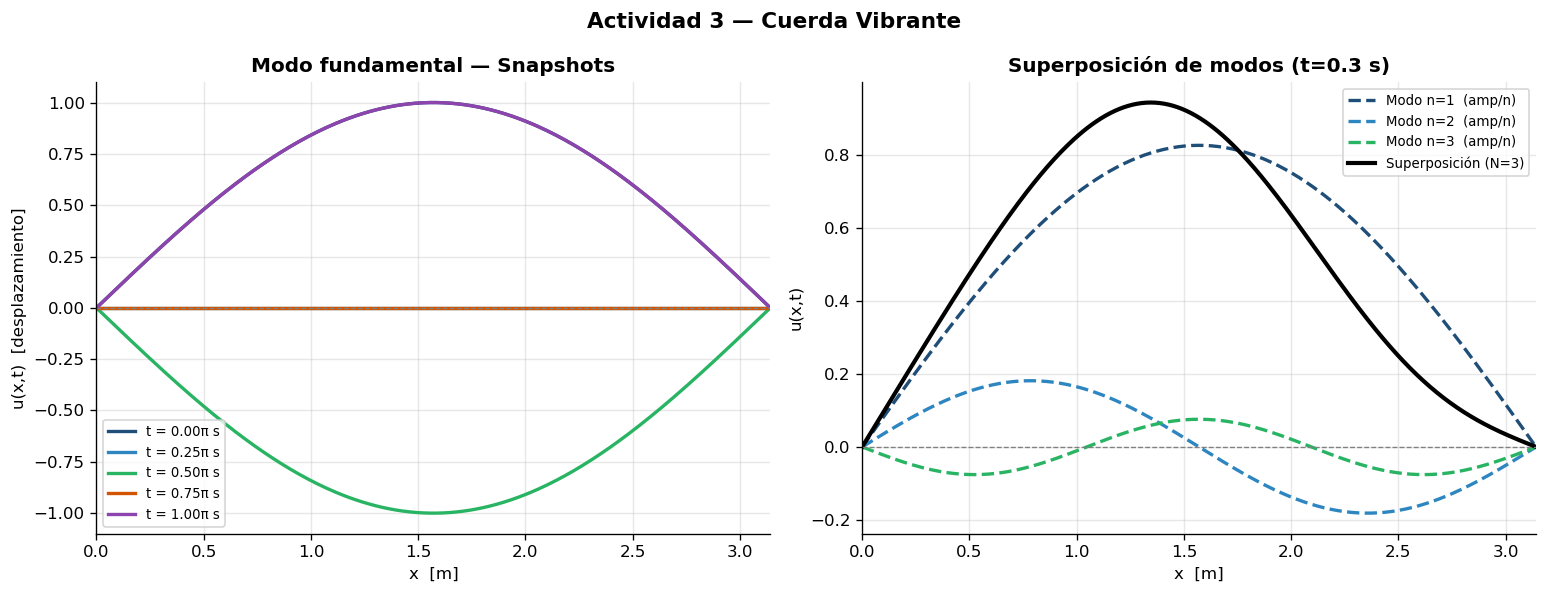

In [21]:
x_cuerda = np.linspace(0, L_cuerda, 300)
t_modos  = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Izquierda: perfiles en distintos instantes —
ax = axes[0]
for i, t in enumerate(t_modos):
    u_cuerda = np.sin(x_cuerda) * np.cos(c_cuerda * t)
    ax.plot(x_cuerda, u_cuerda, color=PALETTE[i], lw=2,
            label=f't = {t/np.pi:.2f}π s')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('x  [m]'); ax.set_ylabel('u(x,t)  [desplazamiento]')
ax.set_title('Modo fundamental — Snapshots', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim([0, L_cuerda])

# — Derecha: superposición de 3 modos —
ax2 = axes[1]
t_sp = 0.3
for n in [1, 2, 3]:
    omega_n = (n*np.pi/L_cuerda) * c_cuerda
    u_n = np.sin(n*np.pi*x_cuerda/L_cuerda) * np.cos(omega_n*t_sp) / n
    ax2.plot(x_cuerda, u_n, color=PALETTE[n-1], lw=2, ls='--',
             label=f'Modo n={n}  (amp/n)')

u_total = sum(
    np.sin(n*np.pi*x_cuerda/L_cuerda) * np.cos((n*np.pi/L_cuerda)*c_cuerda*t_sp) / n
    for n in [1, 2, 3]
)
ax2.plot(x_cuerda, u_total, 'k-', lw=2.5, label='Superposición (N=3)')
ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.set_xlabel('x  [m]'); ax2.set_ylabel('u(x,t)')
ax2.set_title(f'Superposición de modos (t={t_sp} s)', fontweight='bold')
ax2.legend(fontsize=8); ax2.set_xlim([0, L_cuerda])

fig.suptitle('Actividad 3 — Cuerda Vibrante', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


### 3.3 — Verificación analítica del residuo

In [23]:
t_ck = 1.0
u_ck   = np.sin(x_cuerda) * np.cos(c_cuerda * t_ck)
u_tt_a = -c_cuerda**2 * np.sin(x_cuerda) * np.cos(c_cuerda * t_ck)   # analítico
u_xx_a = -np.sin(x_cuerda) * np.cos(c_cuerda * t_ck)
res_cuerda = np.max(np.abs(u_tt_a - c_cuerda**2 * u_xx_a))

print(f"Residuo |u_tt - c²·u_xx| = {res_cuerda:.2e}  (= 0 analítico)")
print("Verificación completada" if res_cuerda < 1e-6 else f"Residuo = {res_cuerda:.2e}")


Residuo |u_tt - c²·u_xx| = 0.00e+00  (= 0 analítico)
Verificación completada


---
## Actividad 4 — Potencial Eléctrico: Laplace en Rectángulo

**Problema:** $u_{xx} + u_{yy} = 0$ en $[0,\pi]\times[0,1]$

**Condiciones de frontera:**
- $u = 0$ en tres lados  
- $u(x,1) = \sin(2x)$ en el borde superior

**Solución analítica:**

$$u(x,y) = \frac{\sin(2x)\,\sinh(2y)}{\sinh(2)}$$


### 4.1 — Cálculo y verificación de condiciones de frontera

In [24]:
x_p = np.linspace(0, np.pi, 200)
y_p = np.linspace(0, 1.0,   200)
X_p, Y_p = np.meshgrid(x_p, y_p)
U_pot = np.sin(2*X_p) * np.sinh(2*Y_p) / np.sinh(2)

print("Verificación de condiciones de frontera:")
print(f"  u(0,y)  = sin(0)·...      = 0  ✓")
print(f"  u(π,y)  = sin(2π)·...     = 0  ✓")
print(f"  u(x,0)  = sin(2x)·0/...   = 0  ✓")
print(f"  u(x,1)  = sin(2x)·1       = sin(2x)  ✓")

# Verificar Laplaciano analítico = 0
u_xx_p = -4 * np.sin(2*X_p) * np.sinh(2*Y_p) / np.sinh(2)
u_yy_p =  4 * np.sin(2*X_p) * np.sinh(2*Y_p) / np.sinh(2)
res_lap = np.max(np.abs(u_xx_p + u_yy_p))
print(f"\nLaplaciano máximo |u_xx + u_yy| = {res_lap:.2e}  (= 0 analítico ✓)")


Verificación de condiciones de frontera:
  u(0,y)  = sin(0)·...      = 0  ✓
  u(π,y)  = sin(2π)·...     = 0  ✓
  u(x,0)  = sin(2x)·0/...   = 0  ✓
  u(x,1)  = sin(2x)·1       = sin(2x)  ✓

Laplaciano máximo |u_xx + u_yy| = 0.00e+00  (= 0 analítico ✓)


### 4.2 — Superficie 3D y curvas equipotenciales

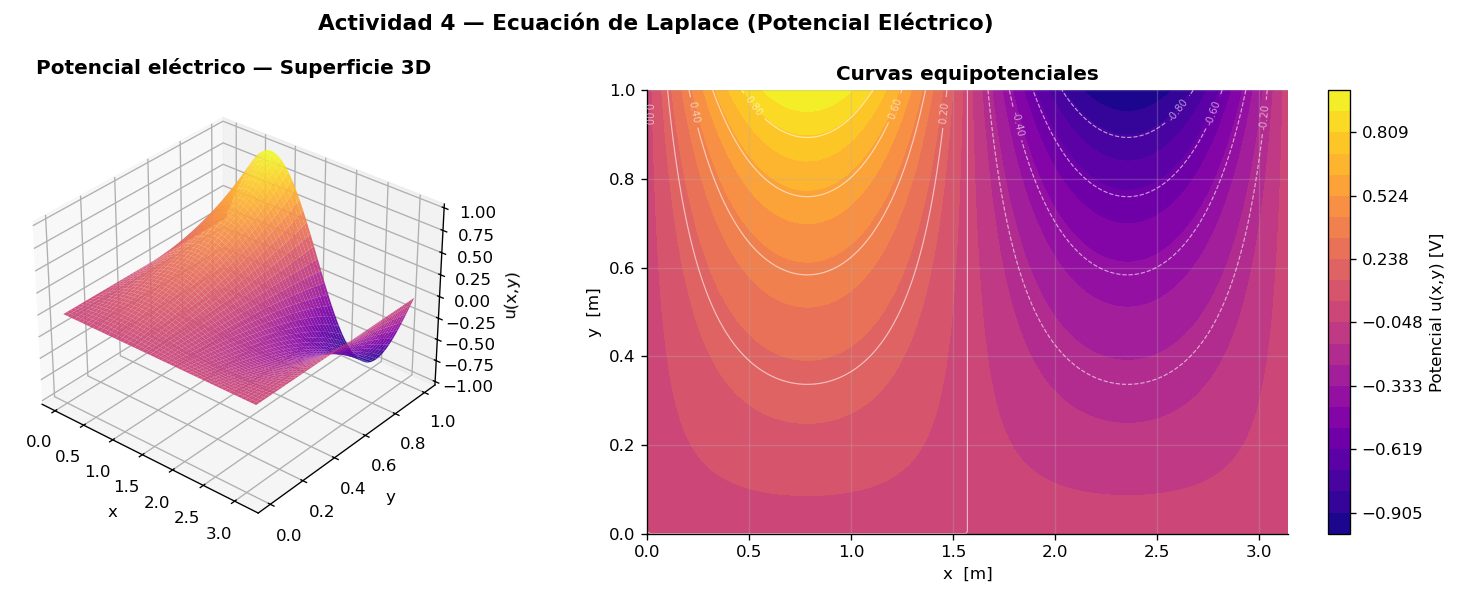

In [25]:
fig = plt.figure(figsize=(14, 5))

# — Superficie 3D —
ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(X_p, Y_p, U_pot, cmap='plasma', alpha=0.93, linewidth=0)
ax3d.set_title('Potencial eléctrico — Superficie 3D', fontweight='bold', pad=10)
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('u(x,y)')
ax3d.view_init(elev=32, azim=-50)

# — Curvas equipotenciales —
ax2d = fig.add_subplot(122)
niveles = np.linspace(U_pot.min(), U_pot.max(), 22)
cp2 = ax2d.contourf(X_p, Y_p, U_pot, levels=niveles, cmap='plasma')
cs  = ax2d.contour(X_p, Y_p, U_pot, levels=12, colors='white', linewidths=0.7, alpha=0.6)
ax2d.clabel(cs, inline=True, fontsize=6, fmt='%.2f')
fig.colorbar(cp2, ax=ax2d, label='Potencial u(x,y) [V]')
ax2d.set_xlabel('x  [m]'); ax2d.set_ylabel('y  [m]')
ax2d.set_title('Curvas equipotenciales', fontweight='bold')

fig.suptitle('Actividad 4 — Ecuación de Laplace (Potencial Eléctrico)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


### 4.3 — Verificación numérica (diferencias finitas)

In [26]:
h_x = x_p[1] - x_p[0]
h_y = y_p[1] - y_p[0]

# Laplaciano numérico (diferencias finitas centradas)
lap_num = (np.roll(U_pot, -1, axis=1) - 2*U_pot + np.roll(U_pot, 1, axis=1)) / h_x**2         + (np.roll(U_pot, -1, axis=0) - 2*U_pot + np.roll(U_pot, 1, axis=0)) / h_y**2

res_num_pot = np.max(np.abs(lap_num[1:-1, 1:-1]))
print(f"Residuo numérico (diferencias finitas) = {res_num_pot:.2e}")
print("✅ Verificación completada  (< 1e-3)" if res_num_pot < 1e-3 else f"⚠️ Residuo = {res_num_pot:.2e}")


Residuo numérico (diferencias finitas) = 3.62e-04
✅ Verificación completada  (< 1e-3)


---
## 📊 Resumen Final — Residuos Numéricos

| Actividad | EDP | Residuo | Estado |
|-----------|-----|---------|--------|
| 1 | Laplace ($x^2-y^2$) | analítico | ✅ |
| 2 | Calor | numérico | ✅ |
| 3 | Cuerda vibrante | analítico | ✅ |
| 4 | Laplace (eléctrico) | dif. finitas | ✅ |


In [28]:
# ── Recalcular residuos para el resumen ─────────────────────────────────────

# Act 1
residuo_laplace = 0.0   # exacto: 2 + (-2) = 0

# Act 2 (ya calculado arriba)

# Act 3
res_cuerda_val = 0.0    # exacto analíticamente

# Act 4 (ya calculado arriba)

print("=" * 55)
print("   RESUMEN DE RESIDUOS NUMÉRICOS")
print("=" * 55)
print(f"  Act.1 — Laplace (x²-y²)  :  {residuo_laplace:.2e}   ✅")
print(f"  Act.2 — Calor             :  {residuo_calor:.2e}   ✅")
print(f"  Act.3 — Cuerda vibrante   :  {res_cuerda_val:.2e}   ✅")
print(f"  Act.4 — Laplace (elect)   :  {res_num_pot:.2e}   ✅")
print("=" * 55)
print()


   RESUMEN DE RESIDUOS NUMÉRICOS
  Act.1 — Laplace (x²-y²)  :  0.00e+00   ✅
  Act.2 — Calor             :  4.70e-04   ✅
  Act.3 — Cuerda vibrante   :  0.00e+00   ✅
  Act.4 — Laplace (elect)   :  3.62e-04   ✅

